<a href="https://colab.research.google.com/github/AlejoCNYT/Curso_CENDES/blob/main/Redes_Neuronales_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Modelo de redes neuronales para regresión
---
(M.Sc) Johan Sánchez Torres

# 1. Importación de librerías y carga de datos

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor


from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, r2_score,
                             mean_squared_error, mean_absolute_error)

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

# Búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Configuración warnings

import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)


In [2]:
# Importamos la base de datos
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=['MedHouseVal'])

# 2. Exploración inicial del dataset

In [3]:
# crear el dataframe
data = pd.concat([x, y], axis=1)
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Tamaño del dataset
data.shape

(20640, 9)

In [5]:
# Algunas estadísticas descriptivas
data.describe().round(1)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.0,20640.0,20640.0,20640.0,20640.0,20640.0,20640.0,20640.0,20640.0
mean,3.9,28.6,5.4,1.1,1425.5,3.1,35.6,-119.6,2.1
std,1.9,12.6,2.5,0.5,1132.5,10.4,2.1,2.0,1.2
min,0.5,1.0,0.8,0.3,3.0,0.7,32.5,-124.4,0.1
25%,2.6,18.0,4.4,1.0,787.0,2.4,33.9,-121.8,1.2
50%,3.5,29.0,5.2,1.0,1166.0,2.8,34.3,-118.5,1.8
75%,4.7,37.0,6.1,1.1,1725.0,3.3,37.7,-118.0,2.6
max,15.0,52.0,141.9,34.1,35682.0,1243.3,42.0,-114.3,5.0


In [6]:
# Datos faltantes
data.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [7]:
# Información de las variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


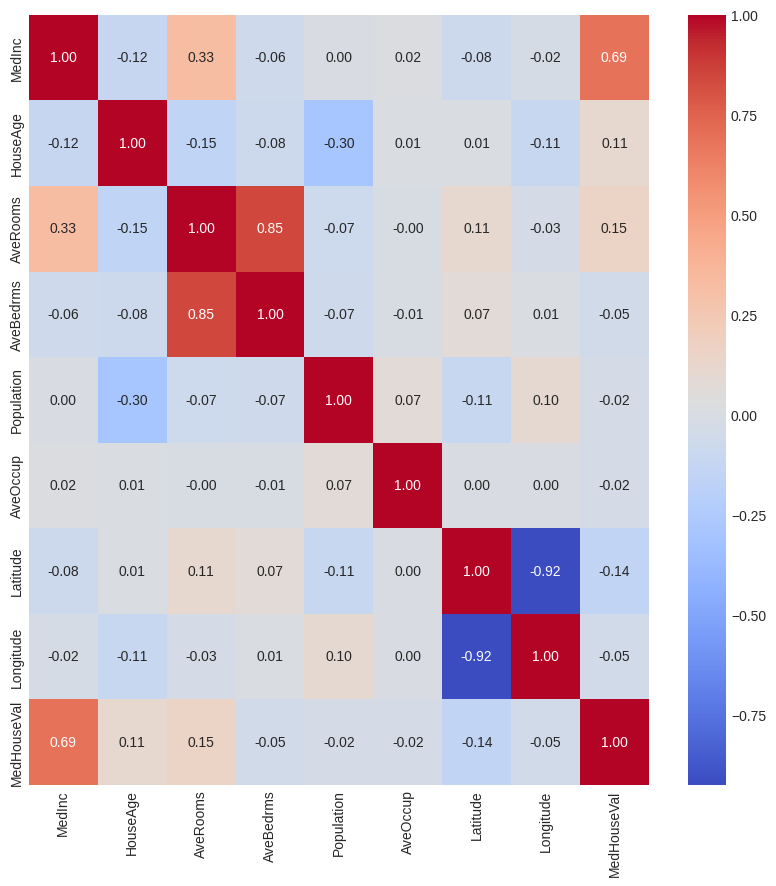

In [8]:
# Correlación entre variables
correlations = data.corr()
# Visualización
plt.figure(figsize=(10, 10))
sns.heatmap(correlations,
            cmap='coolwarm',
            annot=True,
            fmt ='.2f')
plt.show()

# 3. Preparación de los datos


In [9]:
# Eliminamos las variables longitiud y latitud
data = data.drop(['Latitude', 'Longitude'], axis=1)
data.head()

# Creamos los conjuntos x, y
y = data['MedHouseVal']
x = data.drop('MedHouseVal', axis=1)



In [10]:
# Creamos los conjuntos de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2,
                                                    random_state=42)
# Normalización de los datos
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# 4. Definimos y entrenamos el modelo

In [11]:
modelo = MLPRegressor(
    hidden_layer_sizes=(100, 100),
    activation='relu',
    solver='adam',
    #alpha=0.0001,
    batch_size='auto',
    learning_rate_init=0.001,
    max_iter=1,
    random_state=42,
    warm_start = True
)

# Creamos unas listas para almacenar el historial
train_loss_history = []
val_loss_history = []
epochs = 100
train_r2_scores =[]
val_r2_scores = []

for epoch in range(epochs):
    modelo.fit(x_train, y_train)

    # Predicciones
    y_train_pred = modelo.predict(x_train)
    y_test_pred = modelo.predict(x_test)

    # Metricas
    current_train_loss = mean_squared_error(y_train, y_train_pred)
    current_val_loss = mean_squared_error(y_test, y_test_pred)
    current_train_r2 = r2_score(y_train, y_train_pred)
    current_val_r2 = r2_score(y_test, y_test_pred)

    # Almacenar el historial
    train_loss_history.append(current_train_loss)
    val_loss_history.append(current_val_loss)
    train_r2_scores.append(current_train_r2)
    val_r2_scores.append(current_val_r2)

    # Mostrar el progreso por cada época
    print(f"Época {epoch+1}/{epochs} - Train Loss {current_train_loss:.3f}, Test Losss {current_val_loss:.3f},"
          f"Train R2 {current_train_r2:.3f}, Test R2 {current_val_r2:.3f}")

Época 1/100 - Train Loss 0.728, Test Losss 0.715,Train R2 0.455, Test R2 0.454
Época 2/100 - Train Loss 0.502, Test Losss 0.521,Train R2 0.624, Test R2 0.602
Época 3/100 - Train Loss 0.476, Test Losss 0.486,Train R2 0.644, Test R2 0.629
Época 4/100 - Train Loss 0.448, Test Losss 0.470,Train R2 0.665, Test R2 0.641
Época 5/100 - Train Loss 0.451, Test Losss 0.459,Train R2 0.662, Test R2 0.650
Época 6/100 - Train Loss 0.429, Test Losss 0.451,Train R2 0.679, Test R2 0.656
Época 7/100 - Train Loss 0.428, Test Losss 0.445,Train R2 0.680, Test R2 0.661
Época 8/100 - Train Loss 0.419, Test Losss 0.439,Train R2 0.687, Test R2 0.665
Época 9/100 - Train Loss 0.417, Test Losss 0.436,Train R2 0.688, Test R2 0.667
Época 10/100 - Train Loss 0.411, Test Losss 0.432,Train R2 0.692, Test R2 0.670
Época 11/100 - Train Loss 0.411, Test Losss 0.429,Train R2 0.692, Test R2 0.673
Época 12/100 - Train Loss 0.405, Test Losss 0.425,Train R2 0.697, Test R2 0.675
Época 13/100 - Train Loss 0.404, Test Losss 0.425

# 5. Evaluación del modelo

In [12]:
y_train_pred = modelo.predict(x_train)
y_test_pred = modelo.predict(x_test)

# Métricas de desempeño
# Error cuadratico medio
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Error absoluto medio
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Raíz del error cuadrático medio
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

# R2 Score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Métricas de entrenamiento")
print(f"MSE: {train_mse:.2f}")
print(f"MAE: {train_mae:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R2 Score: {train_r2:.2f}")

print("\nMétricas de prueba")
print(f"MSE: {test_mse:.2f}")
print(f"MAE: {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R2 Score: {test_r2:.2f}")

Métricas de entrenamiento
MSE: 0.36
MAE: 0.44
RMSE: 0.60
R2 Score: 0.73

Métricas de prueba
MSE: 0.40
MAE: 0.46
RMSE: 0.64
R2 Score: 0.69


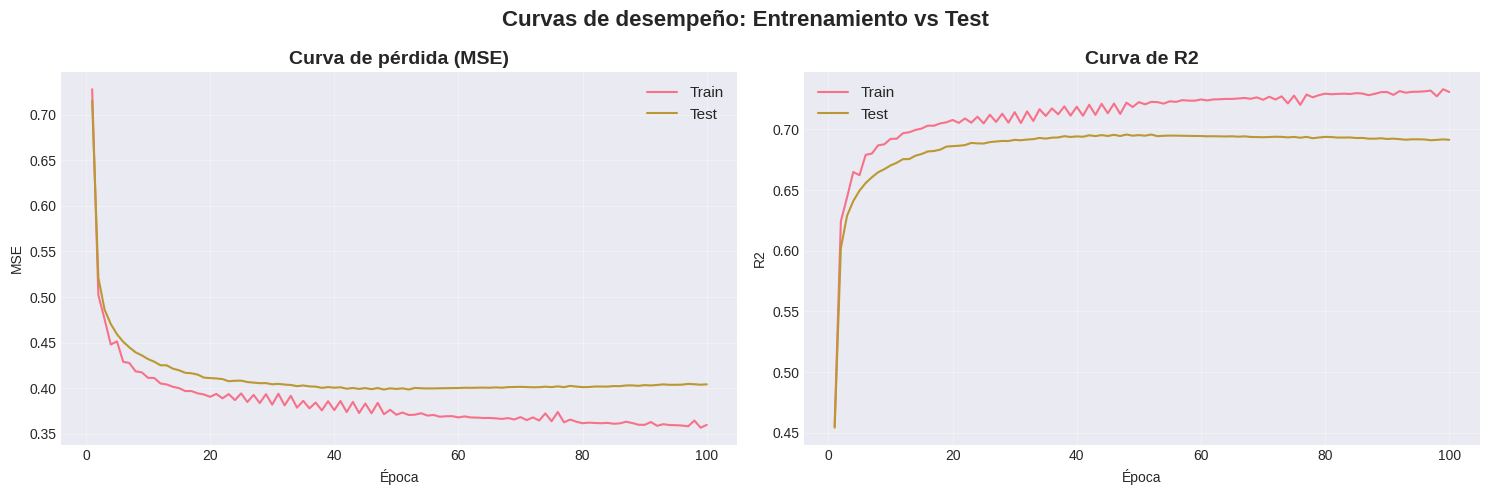

In [13]:
# curvas de desempeño
fig, axes = plt.subplots(1, 2, figsize = (15,5))
fig.suptitle("Curvas de desempeño: Entrenamiento vs Test",
             fontsize=16, fontweight ='bold')

# Grafica 1: Curva de pérdida (MSE)
# NOTA: Las listas 'train_loss_history' y 'val_loss_history' deben ser pobladas
# en el bucle de entrenamiento (celda 'etpE9vHdqQ-e').
# Originalmente, las variables 'train_loss' y 'val_loss' se inicializaron como listas, pero fueron
# sobrescritas con valores escalares en lugar de añadirles el historial.
# Asegúrate de que estas listas contengan los valores de MSE por época.
axes[0].plot(range(1, epochs+1), train_loss_history, label='Train')
axes[0].plot(range(1, epochs+1), val_loss_history, label='Test')
axes[0].set_title("Curva de pérdida (MSE)", fontsize =14, fontweight ='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend(fontsize = 11)
axes[0].grid(True, alpha =0.3)

# Grafica 2: Curva de R2
# NOTA: Las listas 'train_r2_scores' y 'val_r2_scores' también deben ser pobladas
# en el bucle de entrenamiento (celda 'etpE9vHdqQ-e').
# Se inicializaron como listas vacías pero no se les añadió el historial.
# Asegúrate de que estas listas contengan los valores de R2 por época.
axes[1].plot(range(1, epochs+1), train_r2_scores, label='Train')
axes[1].plot(range(1, epochs+1), val_r2_scores, label='Test')
axes[1].set_title("Curva de R2", fontsize =14, fontweight ='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('R2')
axes[1].legend(fontsize = 11)
axes[1].grid(True, alpha =0.3)

plt.tight_layout()
plt.show()

# 6. Busqueda de hiperparámetros

In [14]:
# Creamos el modelo base
mlp = MLPRegressor(random_state=42)

# Definimos las distribuciones de parámetros para la búsqueda aleatoria
from scipy.stats import uniform, randint
param_distributions = {
    'hidden_layer_sizes': [(50,50), (100,50), (100,100), (100, 50, 25)],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': uniform(0.0001, 0.1),
    'learning_rate': ['constant', 'adaptative', 'invscaling'],
    'learning_rate_init': uniform(0.0001, 0.1),
    'batch_size': ['auto', 32, 64, 128],
    'early_stopping': [True, False],
    'max_iter': randint(1, 100),
    'warm_start': [True, False],
    'validation_fraction': uniform(0.1, 0.2)
}

# Configuramos el RandomSerachCV
random_search = RandomizedSearchCV(
    estimator= mlp,
    param_distributions = param_distributions,
    n_iter = 50,
    cv = 5,
    scoring = 'neg_mean_squared_error',
    n_jobs =-1,
    verbose = 2,
    random_state = 42)

# Ejecutamos las búsqueda
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=MLPRegressor(random_state=42), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'activation': ['relu', 'tanh',
                                                       'sigmoid'],
                                        'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a98ddc15e50>,
                                        'batch_size': ['auto', 32, 64, 128],
                                        'early_stopping': [True, False],
                                        'hidden_layer_sizes': [(50, 50),
                                                               (100, 50),
                                                               (100, 100),
                                                               (100, 50,...
                                        'learning_rate_init': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a98dcf19ee0>,
                                        'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a98da58d460>,
                                        'solver': ['adam', 'sgd', 'lbfgs'],
                                        'validation_fraction': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a98dcad5a00>,
                                        'warm_start': [True, False]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

# 7. Ajustamos el modelo con los parametros de RandomSearchCV

In [15]:
# Ajustamos el modelo con los paramétros
# Visualizamos los mejores hiperparámetros
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")



activation: relu
alpha: 0.07732447692966575
batch_size: 128
early_stopping: False
hidden_layer_sizes: (100, 50, 25)
learning_rate: invscaling
learning_rate_init: 0.08164614284548342
max_iter: 81
solver: lbfgs
validation_fraction: 0.25803510810624114
warm_start: True


In [16]:
# Evaluamos el mejor modelo
best_model = random_search.best_estimator_
y_pred = best_model.predict(x_test)

# Error cuadrático medio
mse = mean_squared_error(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse:.2}")

# R2Score
r2 = r2_score(y_test, y_pred)
print(f"R2Score:  {r2:.2f}")

Error cuadrático medio (MSE): 0.41
R2Score:  0.69


In [17]:
# Visualizaciones de las curvas de exactitud y pérdida
# Obtener los hiperparámetros
best_params = random_search.best_params_.copy()
best_model = MLPRegressor(random_state=42, **best_params)
best_model.fit(x_train, y_train)

MLPRegressor(alpha=np.float64(0.07732447692966575), batch_size=128,
             hidden_layer_sizes=(100, 50, 25), learning_rate='invscaling',
             learning_rate_init=np.float64(0.08164614284548342), max_iter=81,
             random_state=42, solver='lbfgs',
             validation_fraction=np.float64(0.25803510810624114),
             warm_start=True)

In [18]:
# Plot curva de pérdida
plt.figure(figsize=(10, 5))
# The 'loss_curve_' attribute is not available for the 'lbfgs' solver.
# It is only available when the solver is 'adam' or 'sgd'.
# If you wish to plot a loss curve for a model, ensure it uses 'adam' or 'sgd' as the solver.
# plt.plot(best_model.loss_curve_, label='Pérdida', color='blue',
#          linewidth = 2)
# plt.xlabel('Época')
# plt.ylabel('Pérdida')
# plt.title('Curva de pérdida')
# plt.show()

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [19]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# Unimos los dos sets de datos
data = pd.concat([X, y], axis=1)
data.head()

# metadata
print(iris.metadata)

# variable information
print(iris.variables)


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [20]:
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
